<a href="https://colab.research.google.com/github/liliettemorejon/ML-for-NLP/blob/main/Confusion_Matrix_Group4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Confusion matrix of the character model (ISM 6642, Group 4)

Which characters does the CNN mix up? This notebook loads the **saved weights from the GitHub repo** (nothing is trained, so the weights and numbers do not change) and reads the **EMNIST ByClass test split**: 36 classes (0-9 and A-Z), images the model never saw during training.

- Raw model reads, **before any business rule**.
- Models: `char_cnn_aug_best.pt` (augmented, the one the demo uses) and `char_cnn_best.pt` (baseline).
- Runs in a few minutes on a Colab CPU; the EMNIST download (~560 MB) is the slowest step.
- The last cell saves the matrix as a picture and a CSV so they can be uploaded to the repo.

## 1. Setup and the saved weights from GitHub

In [1]:
import gzip, shutil, subprocess, zipfile, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

REPO_URL = 'https://github.com/liliettemorejon/ML-for-NLP.git'
ROOT = Path('/content') / Path(REPO_URL).stem
if not ROOT.exists():
    subprocess.run(['git', 'clone', '--depth', '1', REPO_URL, str(ROOT)], check=True)
else:
    subprocess.run(['git', '-C', str(ROOT), 'pull', '-q'], check=True)

AUG_PATH  = ROOT / 'models' / 'char_cnn_aug_best.pt'
BASE_PATH = ROOT / 'models' / 'char_cnn_best.pt'
assert AUG_PATH.exists() and BASE_PATH.exists(), 'Weights not found in the repo (models/)'

EMNIST_MAP = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
N_CLASSES = 36                     # 0-9 and A-Z (lowercase dropped: the form only allows capitals)
CLASSES = EMNIST_MAP[:N_CLASSES]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Repo OK:', ROOT, '| weights:', AUG_PATH.name, '+', BASE_PATH.name, '| device:', device)

Repo OK: /content/ML-for-NLP | weights: char_cnn_aug_best.pt + char_cnn_best.pt | device: cpu


## 2. EMNIST test split (same loading and orientation fix as the full notebook)

In [2]:
EMNIST_DIR = Path('/content/emnist'); EMNIST_DIR.mkdir(exist_ok=True)
EMNIST_URL = 'https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip'
needed = [f'emnist-byclass-test-{k}' for k in ('images-idx3-ubyte.gz', 'labels-idx1-ubyte.gz')]

if not all((EMNIST_DIR / n).exists() for n in needed):
    zip_path = Path('/content/emnist_gzip.zip')
    if not zip_path.exists():
        print('Downloading EMNIST (~560 MB) ...')
        subprocess.run(['curl', '-L', '--fail', '-s', '-o', str(zip_path), EMNIST_URL], check=True)
    with zipfile.ZipFile(zip_path) as z:
        for n in needed:
            (EMNIST_DIR / n).write_bytes(z.read(f'gzip/{n}'))

def load_idx_images(path):
    with gzip.open(path, 'rb') as f:
        data = f.read()
    magic, n, rows, cols = np.frombuffer(data[:16], dtype='>i4')
    assert magic == 2051, f"Not an idx image file: {path}"
    return np.frombuffer(data, dtype=np.uint8, offset=16).reshape(n, rows, cols)

def load_idx_labels(path):
    with gzip.open(path, 'rb') as f:
        data = f.read()
    magic, n = np.frombuffer(data[:8], dtype='>i4')
    assert magic == 2049, f"Not an idx label file: {path}"
    return np.frombuffer(data, dtype=np.uint8, offset=8)

x_all = np.ascontiguousarray(load_idx_images(EMNIST_DIR / needed[0]).transpose(0, 2, 1))   # EMNIST is stored transposed
y_all = load_idx_labels(EMNIST_DIR / needed[1])

keep = y_all < N_CLASSES                       # drop lowercase
x_test, y_test = x_all[keep], y_all[keep]

# Orientation check: an average '1' must be taller than wide
mean_one = x_test[y_test == 1][:2000].mean(axis=0)
rows = np.where(mean_one.max(axis=1) > 60)[0]; cols = np.where(mean_one.max(axis=0) > 60)[0]
assert np.ptp(rows) + 1 > np.ptp(cols) + 1, 'Images look sideways, check the transpose'
print(f'Test images: {len(y_test):,} | digits {np.sum(y_test < 10):,} | letters {np.sum(y_test >= 10):,}')

Test images: 89,264 | digits 57,918 | letters 31,346


## 3. The model and its reads on the test split

In [3]:
class CharCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        return F.log_softmax(self.fc2(x), dim=1)

def to_model_input(x_uint8):
    """(N,28,28) uint8, white ink on black -> (N,1,28,28) float in [-1, 1] (same as training and inference)."""
    x = torch.from_numpy(np.asarray(x_uint8)).float().div(255.0)
    return ((x - 0.5) / 0.5).unsqueeze(1)

def log_probs(path):
    m = CharCNN().to(device)
    m.load_state_dict(torch.load(path, map_location=device))
    m.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(x_test), 2048):
            out.append(m(to_model_input(x_test[i:i + 2048]).to(device)).cpu().numpy())
    return np.concatenate(out)

LOGP = {'augmented': log_probs(AUG_PATH), 'baseline': log_probs(BASE_PATH)}

def confusion(pred, true):
    cm = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
    np.add.at(cm, (true, pred), 1)
    return cm

CM = {name: confusion(lp.argmax(axis=1), y_test) for name, lp in LOGP.items()}
for name, cm in CM.items():
    print(f"{name:<10} accuracy on {cm.sum():,} test characters: {np.trace(cm) / cm.sum():.2%}")

augmented  accuracy on 89,264 test characters: 91.03%
baseline   accuracy on 89,264 test characters: 91.71%


## 4. Where the errors are

Most common mix-ups (true character -> character the model read), and the weakest characters. In EMNIST, `0` and `O`, `1` and `I`, `5` and `S`, `2` and `Z` look alike, so many of the confusions are between a digit and its look-alike letter. The real pipeline reduces these by **restricting each field to digits or letters** (section 5).

In [4]:
def top_pairs(cm, k=10):
    pairs = sorted(((cm[i, j], CLASSES[i], CLASSES[j]) for i in range(N_CLASSES)
                    for j in range(N_CLASSES) if i != j and cm[i, j] > 0), reverse=True)
    return pairs[:k]

for name in ('augmented', 'baseline'):
    cm = CM[name]
    print(f'--- {name} model ---')
    print('Most common confusions (true -> read):')
    for n, t, r in top_pairs(cm):
        print(f"  {t} read as {r}: {n:>4} times ({n / cm[CLASSES.index(t)].sum():.1%} of all true {t})")
    recall = cm.diagonal() / cm.sum(axis=1)
    print('Weakest characters:')
    for i in np.argsort(recall)[:5]:
        print(f"  {CLASSES[i]}: {recall[i]:.1%} correct out of {cm[i].sum()}")
    print()

--- augmented model ---
Most common confusions (true -> read):
  O read as 0: 2716 times (65.4% of all true O)
  I read as 1: 1005 times (49.1% of all true I)
  2 read as Z:  534 times (9.1% of all true 2)
  S read as 5:  414 times (11.8% of all true S)
  1 read as I:  397 times (6.3% of all true 1)
  0 read as O:  385 times (6.7% of all true 0)
  5 read as S:  261 times (5.0% of all true 5)
  0 read as D:  139 times (2.4% of all true 0)
  O read as D:   98 times (2.4% of all true O)
  4 read as Y:   92 times (1.6% of all true 4)
Weakest characters:
  O: 30.9% correct out of 4156
  I: 49.1% correct out of 2048
  S: 87.1% correct out of 3508
  0: 88.5% correct out of 5778
  2: 89.1% correct out of 5869

--- baseline model ---
Most common confusions (true -> read):
  O read as 0: 1534 times (36.9% of all true O)
  0 read as O: 1289 times (22.3% of all true 0)
  1 read as I:  799 times (12.6% of all true 1)
  I read as 1:  697 times (34.0% of all true I)
  5 read as S:  384 times (7.4% of

## 5. Does restricting the field help?

On the form, mileage boxes hold only digits and ID/client letter boxes hold only letters. Here every test image is read once with all 36 classes allowed, and once allowed only its own kind (digit images pick among 10 digits, letter images among 26 letters).

In [5]:
rows = []
for name, lp in LOGP.items():
    free = lp.argmax(axis=1)
    masked = lp.copy()
    masked[np.ix_(y_test < 10, np.arange(10, N_CLASSES))] = -np.inf     # digit images: digits only
    masked[np.ix_(y_test >= 10, np.arange(10))] = -np.inf               # letter images: letters only
    restricted = masked.argmax(axis=1)
    for kind, sel in (('digits', y_test < 10), ('letters', y_test >= 10)):
        rows.append({'model': name, 'characters': kind,
                     'all 36 classes allowed': (free[sel] == y_test[sel]).mean(),
                     'restricted to own type': (restricted[sel] == y_test[sel]).mean()})
print(pd.DataFrame(rows).to_string(index=False, float_format='{:.2%}'.format))

    model characters  all 36 classes allowed  restricted to own type
augmented     digits                  94.98%                  99.15%
augmented    letters                  83.72%                  97.38%
 baseline     digits                  92.74%                  99.28%
 baseline    letters                  89.81%                  97.81%


## 6. The confusion matrices (augmented model)

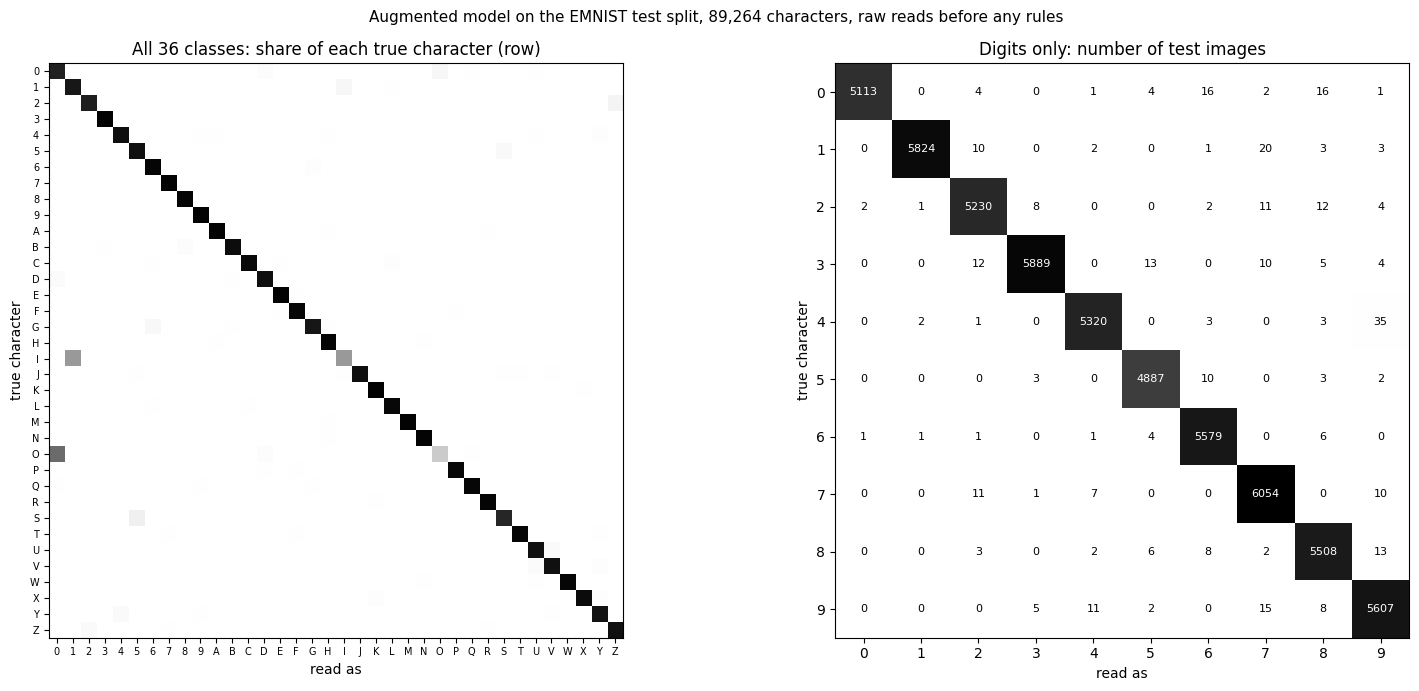

Saved: confusion_matrix_augmented.png, confusion_matrix_augmented.csv, confusion_matrix_baseline.csv


In [6]:
cm = CM['augmented']
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

norm = cm / cm.sum(axis=1, keepdims=True)
axes[0].imshow(norm, cmap='Greys', vmin=0, vmax=1)
axes[0].set_xticks(range(N_CLASSES)); axes[0].set_xticklabels(CLASSES, fontsize=7)
axes[0].set_yticks(range(N_CLASSES)); axes[0].set_yticklabels(CLASSES, fontsize=7)
axes[0].set_title('All 36 classes: share of each true character (row)')

d = cm[:10, :10]
axes[1].imshow(d, cmap='Greys', vmin=0, vmax=d.max())
for i in range(10):
    for j in range(10):
        axes[1].text(j, i, d[i, j], ha='center', va='center', fontsize=8,
                     color='white' if d[i, j] > d.max() / 2 else 'black')
axes[1].set_xticks(range(10)); axes[1].set_yticks(range(10))
axes[1].set_title('Digits only: number of test images')

for ax in axes:
    ax.set_xlabel('read as'); ax.set_ylabel('true character')
plt.suptitle(f"Augmented model on the EMNIST test split, {cm.sum():,} characters, raw reads before any rules", fontsize=11)
plt.tight_layout()
plt.savefig('/content/confusion_matrix_augmented.png', dpi=200, bbox_inches='tight')
plt.show()

pd.DataFrame(cm, index=list(CLASSES), columns=list(CLASSES)).to_csv('/content/confusion_matrix_augmented.csv')
pd.DataFrame(CM['baseline'], index=list(CLASSES), columns=list(CLASSES)).to_csv('/content/confusion_matrix_baseline.csv')
print('Saved: confusion_matrix_augmented.png, confusion_matrix_augmented.csv, confusion_matrix_baseline.csv')

## 7. Download the files (to upload to the GitHub repo)

In [7]:
from google.colab import files
for f in ('confusion_matrix_augmented.png', 'confusion_matrix_augmented.csv', 'confusion_matrix_baseline.csv'):
    files.download('/content/' + f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>